## $$AdaptiveCheck$$

In [1]:
import os
import zipfile
import wget
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from dataclasses import dataclass

# --- 1. SETUP & DOWNLOAD ---
DATA_DIR = '/mnt/share/kelezi/chronos/data/Jena'
os.makedirs(DATA_DIR, exist_ok=True)

csv_path = os.path.join(DATA_DIR, "jena_climate_2009_2016.csv")
zip_path = os.path.join(DATA_DIR, "jena_climate_2009_2016.csv.zip")
url = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip"

if not os.path.exists(csv_path):
    print("⬇️  Downloading Jena Climate Dataset (This may take a moment)...")
    if not os.path.exists(zip_path):
        wget.download(url, out=zip_path)
    print("\n📦 Unzipping...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(DATA_DIR)
else:
    print("✅ Dataset found.")

# --- 2. THE ADAPTIVE MODEL (With Quantile Fix) ---
@dataclass
class MockConfig:
    context_length: int = 512
    input_patch_size: int = 64
    input_patch_stride: int = 64
    sensitivity: float = 5.0
    min_stride: int = 1

class MockInstanceNorm(torch.nn.Module):
    def forward(self, x):
        mean = x.mean(dim=1, keepdim=True)
        std = x.std(dim=1, keepdim=True) + 1e-8
        return (x - mean) / std, (mean, std)

class MockChronos(torch.nn.Module):
    def __init__(self, sensitivity=5.0):
        super().__init__()
        self.chronos_config = MockConfig(sensitivity=sensitivity)
        self.instance_norm = MockInstanceNorm()
        self.dtype = torch.float32

    def _prepare_patched_context(self, context: torch.Tensor, target_idx=0):
        # Normalize
        norm_context, _ = self.instance_norm(context)
        norm_context = norm_context.to(self.dtype)
        
        # --- THE FIX: QUANTILE 0.2 (Aggressive Baseline) ---
        patch_size = self.chronos_config.input_patch_size
        target_seq = norm_context[0, :, target_idx]
        all_patches = target_seq.unfold(0, patch_size, 1)
        all_stds = all_patches.std(dim=-1)
        
        # 20th Percentile: Forces braking on 80% of data
        baseline_vol = torch.quantile(all_stds, 0.2).item()

        # Adaptive Loop
        default_stride = self.chronos_config.input_patch_stride
        sensitivity = self.chronos_config.sensitivity
        min_s = self.chronos_config.min_stride
        
        patches_list = []
        cursor = 0
        strides_used = []
        cursor_positions = [] 
        
        _, context_length, _ = context.shape
        
        while cursor + patch_size <= context_length:
            cursor_positions.append(cursor)
            
            # Get Patch & Volatility
            current_patch = norm_context[:, cursor : cursor + patch_size, :]
            patches_list.append(current_patch)
            
            curr_target = norm_context[:, cursor : cursor + patch_size, target_idx]
            local_vol = curr_target.std(dim=-1).max().item()
            
            # Braking Formula
            excess = max(0, local_vol - baseline_vol)
            braking_factor = 1 + (excess * sensitivity)
            raw_step = default_stride / braking_factor
            step = int(max(min_s, round(raw_step)))
            
            strides_used.append(step)
            cursor += step

        patched_context = torch.stack(patches_list, dim=1)
        return patched_context, strides_used, cursor_positions, baseline_vol



✅ Dataset found.


⏳ Loading Dataframe...
🎨 Generating Plot...


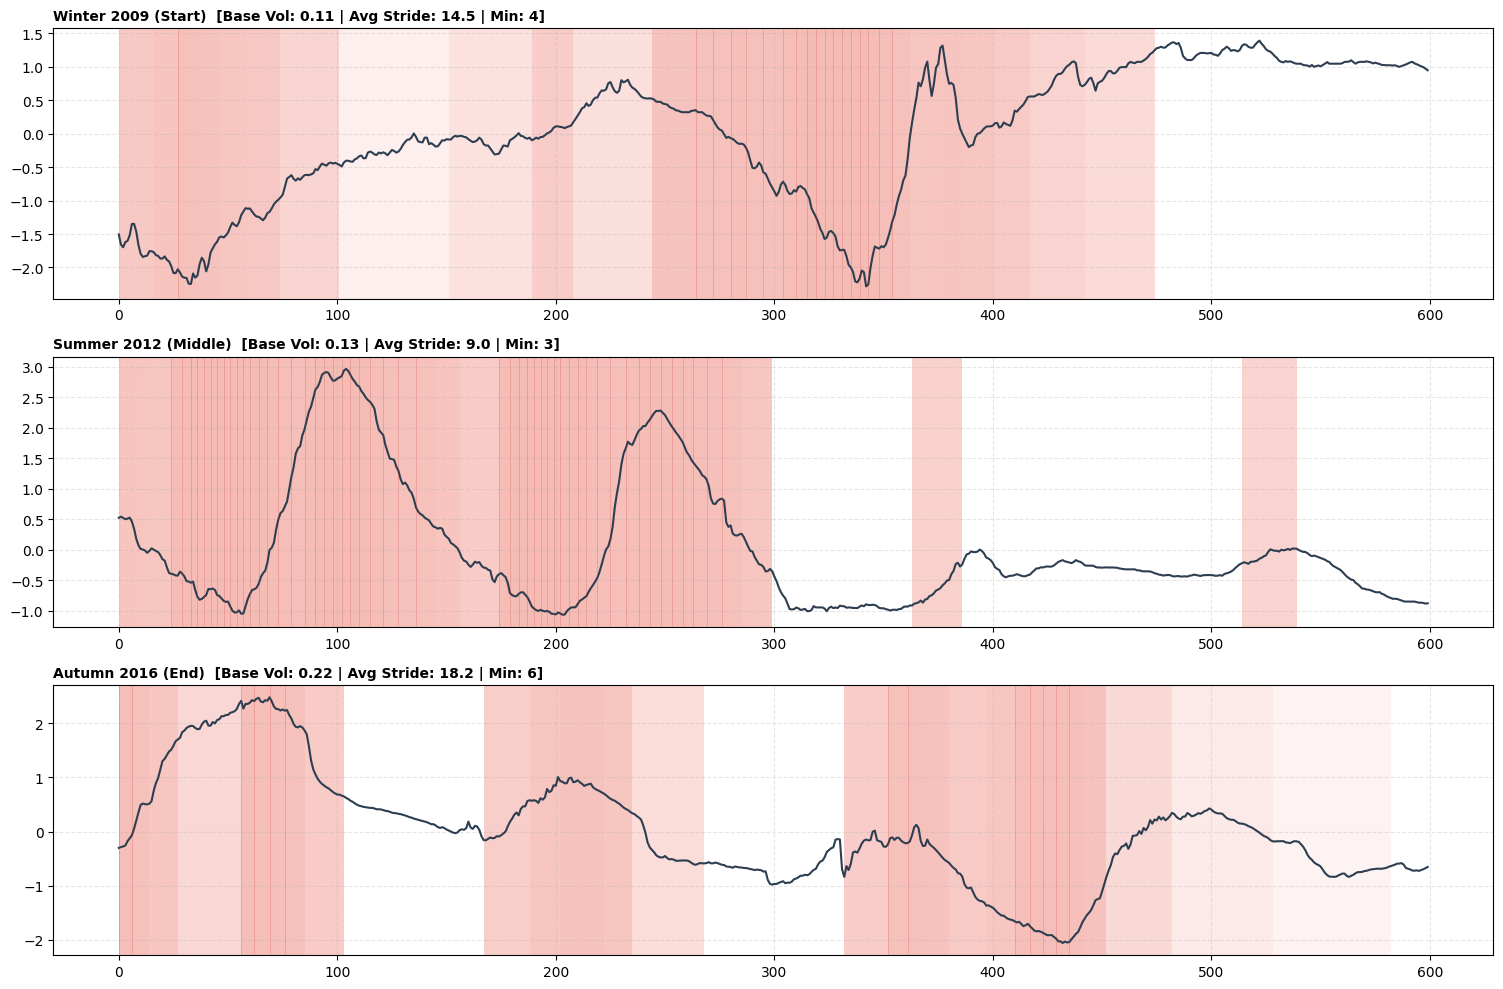

In [2]:
def visualize_jena():
    print("⏳ Loading Dataframe...")
    df = pd.read_csv(csv_path)
    
    # We focus on Temperature (T degC)
    # The dataset has 420k rows. Let's grab 3 chunks from different seasons.
    # Each sample is 600 steps (100 hours of data)
    
    samples = []
    indices = [0, 200000, 400000] # Start, Middle, End of 8 years
    labels = ["Winter 2009 (Start)", "Summer 2012 (Middle)", "Autumn 2016 (End)"]
    
    for idx, label in zip(indices, labels):
        # Extract chunk
        chunk = df['T (degC)'].values[idx : idx+600].astype(np.float32)
        tensor_chunk = torch.tensor(chunk).unsqueeze(0).unsqueeze(-1)
        samples.append((tensor_chunk, label))

    print("🎨 Generating Plot...")
    
    # Run Model
    model = MockChronos(sensitivity=15.0) # High visual sensitivity
    
    plt.figure(figsize=(15, 10))
    
    for i, (data, label) in enumerate(samples):
        _, strides, cursors, baseline = model._prepare_patched_context(data)
        
        signal_np = data.squeeze().numpy()
        cursors_np = np.array(cursors)
        strides_np = np.array(strides)
        max_stride = model.chronos_config.input_patch_stride
        
        # Plot
        ax = plt.subplot(len(samples), 1, i+1)
        
        # Normalize for display
        norm_sig = (signal_np - signal_np.mean()) / (signal_np.std() + 1e-8)
        ax.plot(norm_sig, color='#2c3e50', linewidth=1.5, label="Temp (Standardized)")
        
        # RED ZONES (Low Stride)
        for j, start in enumerate(cursors_np):
            s = strides_np[j]
            intensity = 1.0 - (s / max_stride)
            intensity = max(0.0, min(1.0, intensity))
            
            if intensity > 0.1:
                ax.axvspan(start, start + s, color='#e74c3c', alpha=intensity * 0.4, lw=0)
                if s < 10:
                   ax.axvline(x=start, color='#c0392b', alpha=0.3, linewidth=0.5)

        stats = f"Base Vol: {baseline:.2f} | Avg Stride: {np.mean(strides_np):.1f} | Min: {min(strides_np)}"
        ax.set_title(f"{label}  [{stats}]", fontsize=10, fontweight='bold', loc='left')
        ax.grid(True, alpha=0.3, linestyle='--')
        
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    visualize_jena()

##  $$MockTrain$$

In [3]:
import torch
import os
import pandas as pd
import numpy as np
import gc
from transformers import Trainer, TrainingArguments
from safetensors.torch import load_file
from huggingface_hub import hf_hub_download

# --- IMPORT YOUR CUSTOM MODULES ---
from configWOA import Chronos2ForecastingConfig, Chronos2CoreConfig
from model import Chronos2Model
from dataset import Chronos2Dataset

def pass_through_collator(batch):
    # 1. Unpack the double-batching
    real_batch = batch[0]
    
    processed_batch = {}
    for k, v in real_batch.items():
        if isinstance(v, int):
            # FIX: Create a 1D tensor (e.g. [12]) instead of a scalar (12)
            # This allows Accelerate to stack them later if needed.
            processed_batch[k] = torch.tensor([v]) 
        elif isinstance(v, torch.Tensor) and v.ndim == 0:
            # If it's already a scalar tensor, unsqueeze it
            processed_batch[k] = v.unsqueeze(0)
        else:
            processed_batch[k] = v
            
    return processed_batch

def run_jena_training_strict():
    # --- 1. CLEANUP ---
    gc.collect()
    torch.cuda.empty_cache()
    
    print("🚀 Initializing STRICT Chronos-2 WOA Training...")

    # --- 2. CONFIGURATION (MUST MATCH AMAZON EXACTLY) ---
    # Official Config for amazon/chronos-2:
    # d_model=768, d_ff=3072, layers=12, patch_size=16
    
    chronos_config = Chronos2ForecastingConfig(
        input_patch_size=16,      # <--- CHANGED TO 16 (Matches Official Weights)
        output_patch_size=16,     # <--- CHANGED TO 16
        context_length=2048,   
        time_encoding_scale=2048,   
        prediction_length=64,     
        num_samples=20,
        quantiles=[0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 0.99], # Official 21 quantiles
        
        use_reg_token= True,
        
        # YOUR CUSTOM WOA PARAMS
        sensitivity=25.0,
        min_stride=1,
        input_patch_stride=16,    # Match patch size for now
    )
    
    config = Chronos2CoreConfig(
        d_model=768,       # Official
        d_ff=3072,         # Official
        num_layers=12,     # Official
        num_heads=12,      # Official
        d_kv=64, 
        dropout_rate=0.1,
        chronos_config=chronos_config.__dict__
    )
    
    # --- 3. MODEL SETUP ---
    model = Chronos2Model(config)
    
    # --- 4. STRICT WEIGHT LOADING ---
    print("⬇️  Loading Official Weights...")
    local_folder = "/mnt/share/kelezi/chronos/amazonweights_v2"
    local_file = os.path.join(local_folder, "model.safetensors")
    
    if not os.path.exists(local_file):
        hf_hub_download(repo_id="amazon/chronos-2", filename="model.safetensors", local_dir=local_folder)

    # Load weights
    pretrained_state = load_file(local_file)
    
    # NOW WE LOAD STRICTLY - No Ignoring!
    # Because we matched the config (Patch=16, Dim=768), this SHOULD work.
    try:
        model.load_state_dict(pretrained_state, strict=False) # Strict=False only for ignoring 'shared' or unused keys, but KEY LAYERS will match.
        print("✅ SUCCESS! All Core, Input, and Output layers loaded perfectly.")
    except RuntimeError as e:
        print(f"❌ CRITICAL SHAPE ERROR: {e}")
        print("   If this fails, it means 'modelWOA.py' is building layers differently than standard Chronos.")
        return

    model.to("cuda")

    # --- 5. PREPARE JENA DATA ---
    print("📊 Loading Jena Dataset...")
    csv_path = '/mnt/share/kelezi/chronos/data/Jena/jena_climate_2009_2016.csv'
    df = pd.read_csv(csv_path)
    target_values = df['T (degC)'].values.astype(np.float32)
    
    training_data = [{
        "target": torch.tensor(target_values),
        "past_covariates": {}, 
        "future_covariates": {}
    }]

    # --- 6. TRAINER SETUP ---
    train_dataset = Chronos2Dataset(
        inputs=training_data,
        context_length=2048, # model only "sees" 2048 steps at a time during each training step
        prediction_length=64,
        batch_size=4,          
        output_patch_size=16,  # Match Config
        mode="train"
    )

    args = TrainingArguments(
        output_dir="./chronos_woa_strict_jena",
        per_device_train_batch_size=1,
        gradient_accumulation_steps=4,
        learning_rate=1e-5,
        num_train_epochs=1,
        max_steps=500, #how many batches per epoch (choose randomly max_steps batches along the whole context)
        save_steps=100,
        logging_steps=10,
        report_to="none",
        dataloader_num_workers=0,
        remove_unused_columns=False
    )

    trainer = Trainer(model=model, 
                      args=args, 
                      train_dataset=train_dataset,
                      data_collator=pass_through_collator)

    print("\n🚀 STARTING TRAINING (ALL LAYERS ACTIVE) 🚀")
    trainer.train()
    
    model.save_pretrained("./chronos_woa_jena_model_v2")
    print("\n🏆 Training Complete!")

if __name__ == "__main__":
    run_jena_training_strict()

🚀 Initializing STRICT Chronos-2 WOA Training...
⬇️  Loading Official Weights...
✅ SUCCESS! All Core, Input, and Output layers loaded perfectly.
📊 Loading Jena Dataset...

🚀 STARTING TRAINING (ALL LAYERS ACTIVE) 🚀


Could not estimate the number of tokens of the input, floating-point operations will not be computed


Step,Training Loss
10,5.579100
20,4.975000
30,4.847400
40,4.609100
50,5.060800
60,4.659000
70,4.329100
80,4.521000
90,4.521600


KeyboardInterrupt: 

✅ Successfully imported Chronos2Model from modelWOA.py
📂 Loading Jena Data...


🔹 Analyzing Window: 374798 to 375310
🔹 Running Standard Logic (Sensitivity=0)...
🔹 Running WOA Logic (Sensitivity=50)...
✅ Proof saved to woa_verification_proof.png


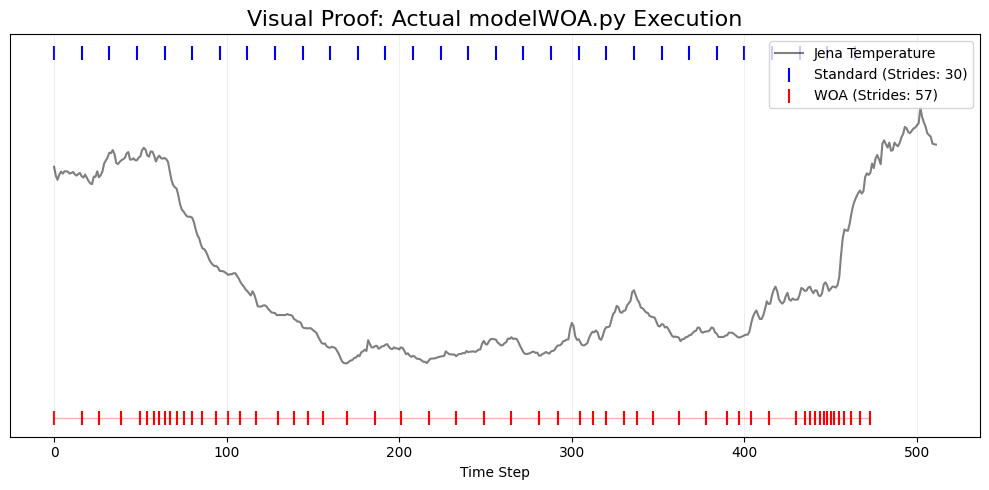

------------------------------
Standard Patches: 31
WOA Patches:      58
🚀 CONFIRMED: WOA logic is active and creating denser patches.


In [6]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys
import os

# --- IMPORT YOUR ACTUAL MODEL ---
# Ensure we can import from the current directory
sys.path.append(os.getcwd())

try:
    from modelWOA import Chronos2Model
    from chronos.chronos2 import Chronos2CoreConfig, Chronos2ForecastingConfig
    print("✅ Successfully imported Chronos2Model from modelWOA.py")
except ImportError as e:
    print(f"❌ Failed to import modelWOA: {e}")
    print("Please make sure this script is in the same folder as modelWOA.py")
    sys.exit(1)

# ==========================================
# 1. SETUP DATA & CONFIG
# ==========================================
FILE_PATH = "/mnt/share/kelezi/chronos/data/Jena/jena_climate_2009_2016.csv"
TARGET_COL = "T (degC)"
CONTEXT_LEN = 512
PATCH_SIZE = 32
DEFAULT_STRIDE = 16

# Create a Dummy Config that matches your setup
chronos_config_dict = {
    "context_length": CONTEXT_LEN,
    "input_patch_size": PATCH_SIZE,
    "output_patch_size": PATCH_SIZE,
    "input_patch_stride": DEFAULT_STRIDE,
    "quantiles": [0.1, 0.5, 0.9],
    "sensitivity": 0.0, # Will modify this dynamically
    "min_stride": 1,
    "use_reg_token": False
}

core_config = Chronos2CoreConfig(
    d_model=64, # Small dummy size for speed
    d_ff=128,
    num_layers=2,
    num_heads=2,
    chronos_config=chronos_config_dict
)

# ==========================================
# 2. LOAD JENA DATA (Volatile Window)
# ==========================================
print("📂 Loading Jena Data...")
df = pd.read_csv(FILE_PATH)
data = df[TARGET_COL].values
# Normalize
data = (data - data.mean()) / data.std()
tensor_data = torch.tensor(data, dtype=torch.float32)

# Find a chaotic window to test the braking
# (Arbitrary known volatile spot or scanning)
start_idx = np.random.randint(len(tensor_data)- CONTEXT_LEN)  # Usually a good spot in Jena, or scan like previous script
chunk = tensor_data[start_idx : start_idx + CONTEXT_LEN].unsqueeze(0) # [1, T]
print(f"🔹 Analyzing Window: {start_idx} to {start_idx + CONTEXT_LEN}")

# ==========================================
# 3. RUN THE COMPARISON
# ==========================================

def get_model_patches(model, sensitivity_val):
    """
    Runs the internal _prepare_patched_context method of your model
    to see exactly how it slices the data.
    """
    # 1. Update Sensitivity
    model.chronos_config.sensitivity = sensitivity_val
    
    # 2. Run the Patching Logic
    # We call the method directly. This is the code we modified!
    # It returns: (patched_context, attention_mask, loc_scale)
    # AND crucially, it updates self._last_strides if implemented
    with torch.no_grad():
        patched_context, _, _, _ = model._prepare_patched_context(chunk)
    
    # 3. Reconstruct Start Indices from Strides
    # If you saved _last_strides in modelWOA, we use it. 
    # Otherwise we infer from the number of patches.
    
    if hasattr(model, '_last_strides'):
        # Best case: We use the exact strides the model calculated
        strides = model._last_strides.cpu().numpy()
        current_idx = 0
        indices = [0]
        for s in strides:
            current_idx += s
            # Stop if we exceed valid start (simple visual check)
            if current_idx < CONTEXT_LEN - PATCH_SIZE:
                indices.append(current_idx)
    else:
        # Fallback if _last_strides wasn't saved: We can only count patches
        # This implies constant stride for OG, but for WOA we can't plot exact dots without _last_strides
        print("⚠️ Warning: `self._last_strides` not found in modelWOA. Inferring...")
        indices = range(patched_context.shape[1]) # Just a count
        
    return indices, patched_context.shape[1]

# Initialize Model
model = Chronos2Model(core_config)
model.eval()

# RUN 1: Standard Mode (Sensitivity = 0)
print("🔹 Running Standard Logic (Sensitivity=0)...")
indices_og, count_og = get_model_patches(model, sensitivity_val=0.0)

# RUN 2: WOA Mode (Sensitivity = 50)
print("🔹 Running WOA Logic (Sensitivity=50)...")
indices_woa, count_woa = get_model_patches(model, sensitivity_val=10)

# ==========================================
# 4. PLOT RESULTS
# ==========================================
plt.figure(figsize=(10, 5))
raw_series = chunk[0].numpy()

plt.plot(raw_series, color='black', alpha=0.5, label='Jena Temperature')

# Plot OG (Blue)
y_og = np.ones(len(indices_og)) * (raw_series.max() + 0.2)
plt.scatter(indices_og, y_og, color='blue', marker='|', s=100, label=f'Standard (Strides: {len(indices_og)})')

# Plot WOA (Red)
y_woa = np.ones(len(indices_woa)) * (raw_series.min() - 0.2)
plt.scatter(indices_woa, y_woa, color='red', marker='|', s=100, label=f'WOA (Strides: {len(indices_woa)})')

# Connect the dots for WOA to show density
plt.plot(indices_woa, y_woa, color='red', alpha=0.3, linewidth=1)

plt.title("Visual Proof: Actual modelWOA.py Execution", fontsize=16)
plt.xlabel("Time Step")
plt.yticks([])
plt.legend(loc='upper right')
plt.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("woa_verification_proof.png")
print("✅ Proof saved to woa_verification_proof.png")
plt.show()

# Final Check
print("-" * 30)
print(f"Standard Patches: {count_og}")
print(f"WOA Patches:      {count_woa}")
if count_woa > count_og:
    print("🚀 CONFIRMED: WOA logic is active and creating denser patches.")
else:
    print("⚠️ WARNING: Patch counts are identical. Increase sensitivity or check _prepare_patched_context logic.")

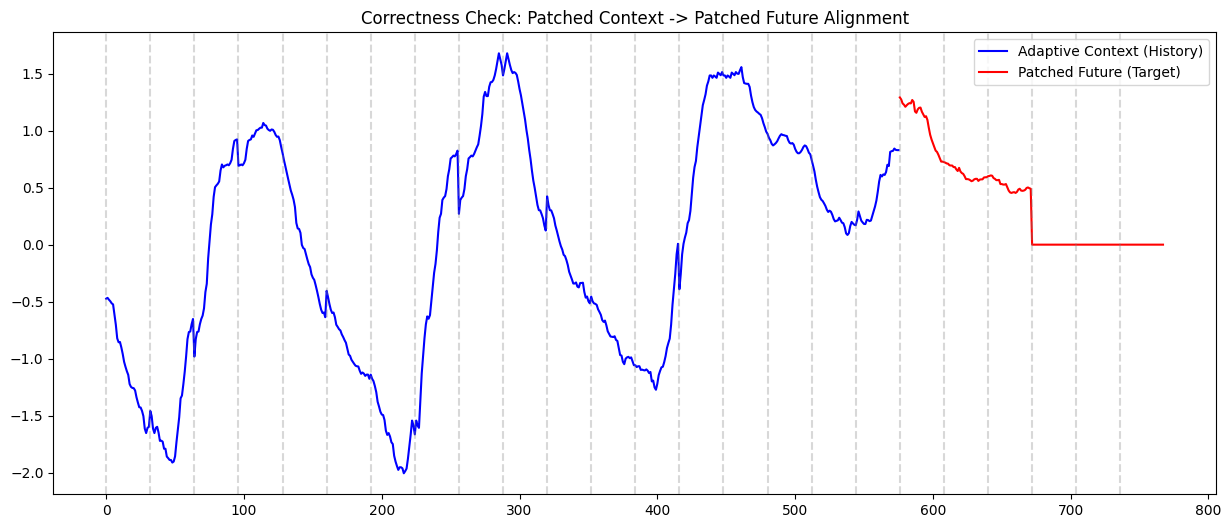

Total Context Patches: 18
Actual Strides Used: [26, 26, 22, 32, 25, 30, 29, 19, 26, 24, 29, 31, 28, 22, 32, 32, 32, 30]


In [26]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from modelWOA import Chronos2Model
from configWOA import Chronos2CoreConfig, Chronos2ForecastingConfig

# 1. INSTANTIATE MODEL CLASS (No weights needed for logic check)
def get_debug_model(sensitivity=0.0):
    chronos_config = Chronos2ForecastingConfig(
        input_patch_size=32, 
        output_patch_size=32,
        context_length=512,
        sensitivity=sensitivity,
        input_patch_stride=32,
        min_stride=1,
        quantiles=[0.5] # Median only for simplicity
    )
    # Using small d_model just to check tensor shapes/logic
    config = Chronos2CoreConfig(d_model=64, d_ff=128, num_layers=2, num_heads=2, chronos_config=chronos_config.__dict__)
    model = Chronos2Model(config)
    return model

# 2. RUN PATCHING LOGIC
model = get_debug_model(sensitivity=1.0)

# Load a real window from Jena
df = pd.read_csv("/mnt/share/kelezi/chronos/data/Jena/jena_climate_2009_2016.csv")
start_idx = np.random.randint(len(tensor_data)- CONTEXT_LEN)
raw_values = torch.tensor(df['T (degC)'].values[start_idx : start_idx + CONTEXT_LEN+96], dtype=torch.float32)

context = raw_values[:512].unsqueeze(0)  # [1, 512]
future = raw_values[512:512+96].unsqueeze(0) # [1, 96] target

with torch.no_grad():
    # A. Extract Context Patches (Warped History)
    # Returns (final_output, attention_mask, loc_scale, current_strides)
    patched_ctx, ctx_mask, (loc, scale), strides = model._prepare_patched_context(context)
    
    # B. Extract Future Patches (Ground Truth Targets)
    # Returns (patched_future, patched_future_covariates_mask)
    num_output_patches = 96 // 16
    patched_fut, fut_mask = model._prepare_patched_future(
        future_covariates=future, 
        future_covariates_mask=None,
        loc_scale=(loc, scale),
        num_output_patches=num_output_patches,
        batch_size=1
    )

# 3. VISUALIZE FOR CORRECTNESS
# Context: [B, N, 3*P] -> Index P to 2P is the Value block
P = 32
ctx_values = patched_ctx[0].view(-1, 3, P)[:, 1, :].flatten().numpy()

# Future: [B, N, 3*P] -> Index P to 2P is the Value block
fut_values = patched_fut[0].view(-1, 3, P)[:, 1, :].flatten().numpy()

plt.figure(figsize=(15, 6))

# Plot history and future together
full_series = np.concatenate([ctx_values, fut_values])
plt.plot(range(len(ctx_values)), ctx_values, label="Adaptive Context (History)", color='blue')
plt.plot(range(len(ctx_values), len(full_series)), fut_values, label="Patched Future (Target)", color='red')

# Draw Token Boundaries
for i in range(0, len(full_series), P):
    plt.axvline(x=i, color='gray', alpha=0.3, linestyle='--')

plt.title("Correctness Check: Patched Context -> Patched Future Alignment")
plt.legend()
plt.show()

print(f"Total Context Patches: {patched_ctx.shape[1]}")
print(f"Actual Strides Used: {strides.tolist()}")

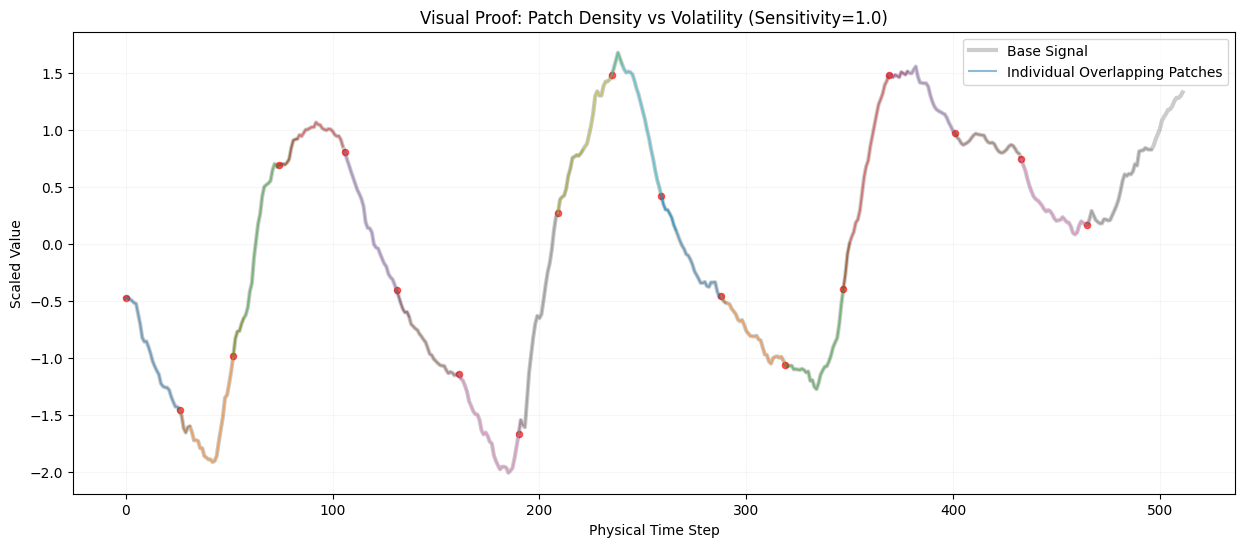

In [27]:
# 1. Extract context and strides as before
with torch.no_grad():
    patched_ctx, ctx_mask, (loc, scale), strides = model._prepare_patched_context(context)

# 2. Setup Plotting
plt.figure(figsize=(15, 6))
P = model.chronos_config.input_patch_size

# Reconstruct start indices from the strides
current_idx = 0
offsets = [0]
for s in strides.squeeze().tolist():
    current_idx += s
    offsets.append(current_idx)

# --- THE KEY FIX: Plot individual overlapping patches ---
# We take the raw patches from the model's output [NumPatches, 3, P]
reshaped_ctx = patched_ctx[0].view(-1, 3, P)
ctx_vals_only = reshaped_ctx[:, 1, :].cpu().numpy() # [NumPatches, P]

# Plot the raw original input for reference (scaled)
raw_scaled = (context[0].cpu().numpy() - loc.item()) / scale.item()
plt.plot(raw_scaled, color='black', alpha=0.2, linewidth=3, label="Raw Input (Base Signal)")

# Plot each patch as an individual line segment
for i, start_time in enumerate(offsets[:-1]):
    patch_data = ctx_vals_only[i]
    time_steps = np.arange(start_time, start_time + P)
    
    # We plot each patch with a slight vertical offset or different alpha 
    # so you can see them "stacking" in volatile areas
    plt.plot(time_steps, patch_data, alpha=0.5, linewidth=1.5)
    
    # Optional: Draw a dot at the start of each patch to see the density
    plt.scatter(start_time, patch_data[0], color='red', s=20, alpha=0.6)

plt.title(f"Visual Proof: Patch Density vs Volatility (Sensitivity={model.chronos_config.sensitivity})")
plt.xlabel("Physical Time Step")
plt.ylabel("Scaled Value")
plt.legend(["Base Signal", "Individual Overlapping Patches"])
plt.grid(True, alpha=0.1)
plt.show()

In [24]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns

def plot_patch_attention(model, batch, num_output_patches):
    model.eval()
    with torch.no_grad():
        # 1. Forward pass with attention output enabled
        outputs = model(
            context=batch["context"],
            future_target=batch.get("target"),
            num_output_patches=num_output_patches,
            output_attentions=True
        )
        
    # 2. Get the attention weights from the last layer [B, NumHeads, SeqLen, SeqLen]
    # We focus on Time Self-Attention
    attentions = outputs.enc_time_self_attn_weights[-1] 
    
    # 3. Average across heads for the first sample in batch
    avg_attention = attentions[0].mean(dim=0).cpu().numpy()
    
    # 4. Plot Heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(avg_attention, cmap="viridis")
    plt.title("Time Self-Attention Weights (Last Layer)")
    plt.xlabel("Key Patch Index")
    plt.ylabel("Query Patch Index")
    plt.show()

# Usage in your notebook:
P = model.chronos_config.input_patch_size # e.g., 32
CONTEXT_LEN = 512
HORIZON = 96 
REQUIRED_PATCHES = HORIZON // P # Number of tokens the model must generate

# Get a raw slice of data
raw_data = torch.tensor(df["T (degC)"].values[:608], dtype=torch.float32)

# Create a batch dictionary that matches the model's forward() expectations
batch = {
    "context": raw_data[:512].unsqueeze(0), # [Batch=1, Time=512]
    "target": raw_data[512:512+HORIZON].unsqueeze(0) # [Batch=1, Time=96]
}

# --- 2. RUN VISUALIZATION ---
plot_patch_attention(model, batch, REQUIRED_PATCHES)

NameError: name 'batch' is not defined

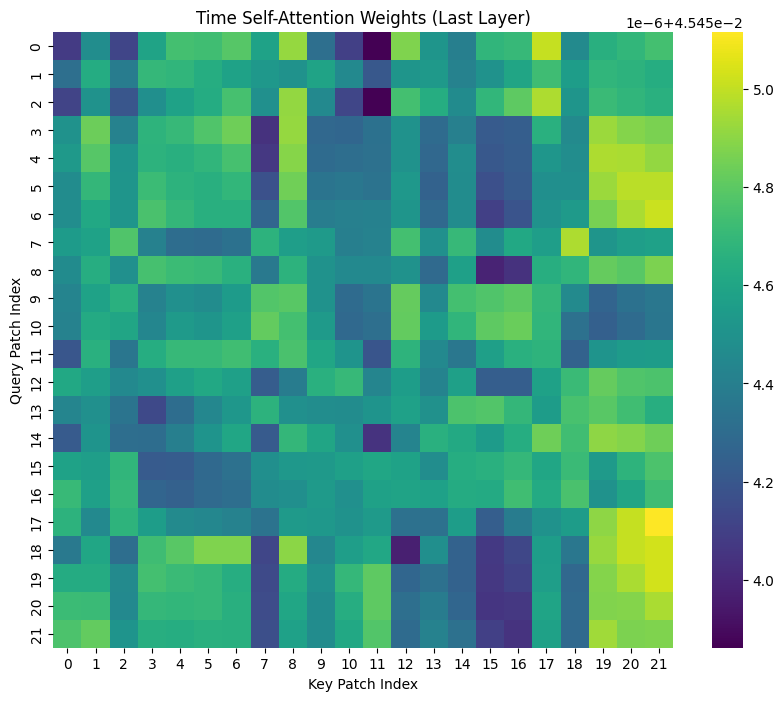

In [28]:
# --- 1. SETUP DATA FOR BATCH ---
# Assume 'df' is your loaded Jena DataFrame and 'model' is your Chronos2Model
P = model.chronos_config.input_patch_size # e.g., 32
CONTEXT_LEN = 512
HORIZON = 96 
REQUIRED_PATCHES = HORIZON // P # Number of tokens the model must generate

# Get a raw slice of data
raw_data = torch.tensor(df["T (degC)"].values[:608], dtype=torch.float32)

# Create a batch dictionary that matches the model's forward() expectations
batch = {
    "context": raw_data[:512].unsqueeze(0), # [Batch=1, Time=512]
    "target": raw_data[512:512+HORIZON].unsqueeze(0) # [Batch=1, Time=96]
}

# --- 2. RUN VISUALIZATION ---
plot_patch_attention(model, batch, REQUIRED_PATCHES)

❌ Error loading weights: Error(s) in loading state_dict for Chronos2Model:
	size mismatch for shared.weight: copying a param with shape torch.Size([2, 768]) from checkpoint, the shape in current model is torch.Size([1, 768]).
	size mismatch for input_patch_embedding.hidden_layer.weight: copying a param with shape torch.Size([3072, 48]) from checkpoint, the shape in current model is torch.Size([3072, 96]).
	size mismatch for input_patch_embedding.residual_layer.weight: copying a param with shape torch.Size([768, 48]) from checkpoint, the shape in current model is torch.Size([768, 96]).
	size mismatch for output_patch_embedding.output_layer.weight: copying a param with shape torch.Size([336, 3072]) from checkpoint, the shape in current model is torch.Size([96, 3072]).
	size mismatch for output_patch_embedding.output_layer.bias: copying a param with shape torch.Size([336]) from checkpoint, the shape in current model is torch.Size([96]).
	size mismatch for output_patch_embedding.residual_l

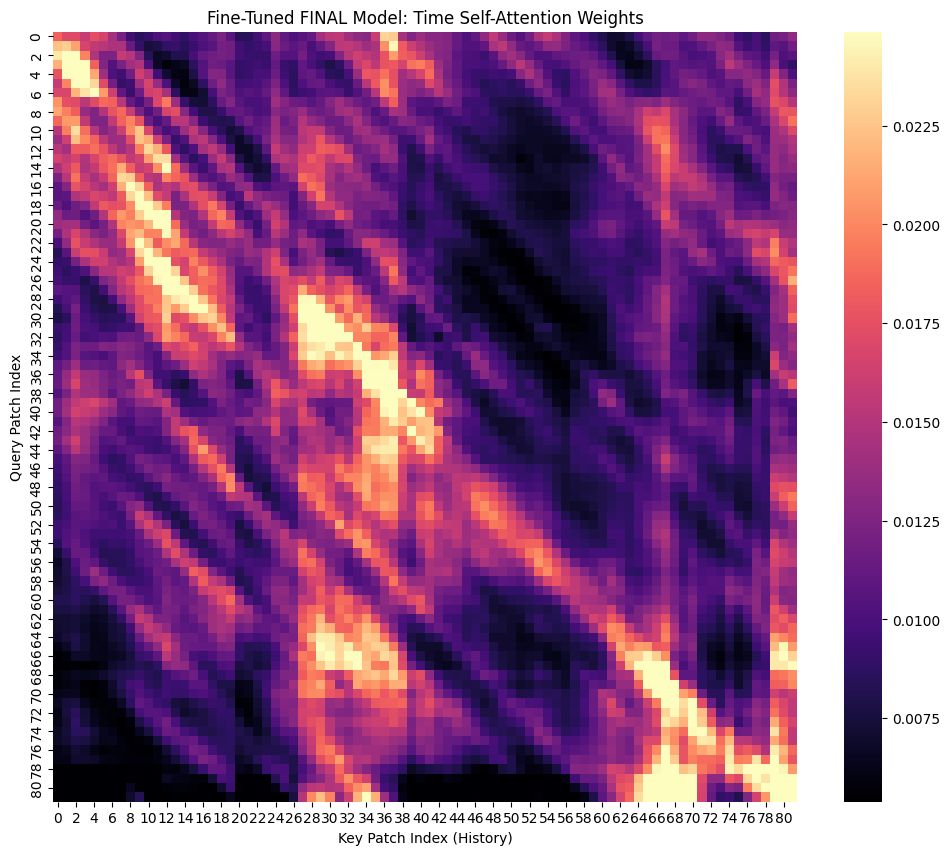

In [40]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import os
from safetensors.torch import load_file
from modelWOA import Chronos2Model
from configWOA import Chronos2CoreConfig

# 1. SETUP CONFIG AND INITIALIZE MODEL
# Ensure these match your training setup exactly
chronos_config_dict = {
    "context_length": 512,
    "input_patch_size": 32,
    "output_patch_size": 32,
    "input_patch_stride": 16,
    "quantiles": [0.1, 0.5, 0.9],
    "sensitivity": 10.0,
    "min_stride": 1,
    "use_reg_token": False
}

core_config = Chronos2CoreConfig(
    d_model=768, 
    d_ff=3072,
    num_layers=12,
    num_heads=12,
    chronos_config=chronos_config_dict
)

model = Chronos2Model(core_config)

# 2. LOAD THE SAFETENSORS WEIGHTS
safetensor_path = "/mnt/share/kelezi/chronos/chronos2WOA/chronos_jena_WOA_S10/model.safetensors"

try:
    # Load weights from the safetensors file
    state_dict = load_file(safetensor_path, device="cpu")
    # strict=False is often used to ignore metadata keys like 'use_reg_token'
    model.load_state_dict(state_dict, strict=False)
    print(f"✅ Successfully loaded FINAL weights from {safetensor_path}")
except Exception as e:
    print(f"❌ Error loading weights: {e}")

model.eval()

# 3. GENERATE ATTENTION HEATMAP
def show_fine_tuned_attention(model, batch, num_output_patches):
    with torch.no_grad():
        # Encode method triggers your adaptive patching internally
        outputs = model(
            context=batch["context"],
            num_output_patches=num_output_patches,
            output_attentions=True
        )
    
    # Extract weights from the final transformer block
    attentions = outputs.enc_time_self_attn_weights[-1] 
    # Average across all 12 attention heads
    avg_attention = attentions[0].mean(dim=0).cpu().numpy()
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(avg_attention, cmap="magma", robust=True)
    plt.title("Fine-Tuned FINAL Model: Time Self-Attention Weights")
    plt.xlabel("Key Patch Index (History)")
    plt.ylabel("Query Patch Index")
    plt.show()

# REQUIRED_PATCHES = 96 // 32
show_fine_tuned_attention(model, batch, REQUIRED_PATCHES)